Step-1 Load data and prepare features/labels

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#import iris dataset and creates dataframe
iris = load_iris()
df = pd.DataFrame(iris.data , columns = iris.feature_names)
df["species"] = iris.target

X = df.drop( "species" , axis = 1 )
y = df["species"]

#seperate training and testing data
X_train , X_test , Y_train ,Y_test = train_test_split( X , y , test_size = 0.2 , random_state = 42 )

Step-2 Create and train the model

In [10]:
from sklearn.neural_network import MLPClassifier
nn_Model = MLPClassifier( hidden_layer_sizes = (10,) , activation='relu' , max_iter = 1000 , random_state = 42 )
nn_Model.fit( X_train , Y_train )

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

Step-3 Make predictions and check accuracy

In [11]:
Y_pred_nn = nn_Model.predict(X_test)
accuracy_nn = accuracy_score( Y_test , Y_pred_nn )
print(f"Neural Network Accuracy:{accuracy_nn:.2f}")

Neural Network Accuracy:0.97


Step-4 Visualize training loss

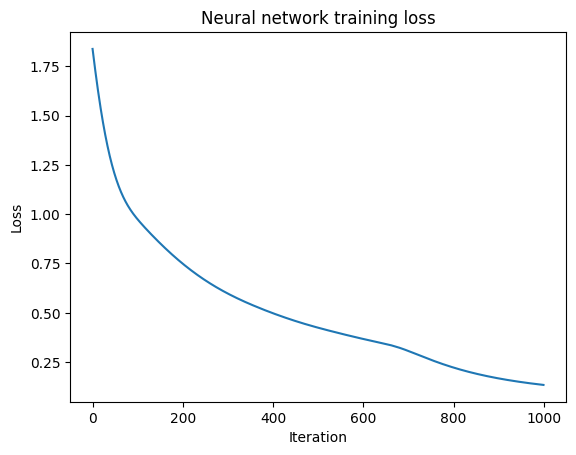

In [12]:
plt.plot(nn_Model.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Neural network training loss")
plt.show()

Step-5 Verify forward pass — scikit-learn's output

In [13]:
# Grab one real flower from the test set
sample = X_test.iloc[[0]]
true_label = Y_test.iloc[0]

# scikit-learn's own answer, for comparison
sklearn_probs = nn_Model.predict_proba(sample)
print("scikit-learn's Softmax output:", sklearn_probs)

scikit-learn's Softmax output: [[0.01159388 0.84118424 0.14722189]]


Step-6 Verify forward pass — manual calculation

In [14]:
# Manually replicate the forward pass, using the REAL trained weights
hidden_z = np.dot(sample, nn_Model.coefs_[0]) + nn_Model.intercepts_[0]
hidden_activated = np.maximum(0, hidden_z)  # ReLU

output_z = np.dot(hidden_activated, nn_Model.coefs_[1]) + nn_Model.intercepts_[1]

print("Raw output z-values:", output_z)

exp_z = np.exp(output_z)
manual_softmax = exp_z / np.sum(exp_z)
print("Manually calculated Softmax output:", manual_softmax)
print("True label:", true_label)

Raw output z-values: [[-2.87382211  1.41051157 -0.33235825]]
Manually calculated Softmax output: [[0.01159388 0.84118424 0.14722189]]
True label: 1


Evaluation Metrics

In [15]:
# confusion_matrix and classification_report

#import functions
from sklearn.metrics import confusion_matrix, classification_report

#print the values
print(confusion_matrix(Y_test, Y_pred_nn))
print(classification_report(Y_test, Y_pred_nn, target_names=["setosa","versicolor","virginica"]))

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [16]:
#Training time
import time

start = time.time()
nn_Model = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=1000, random_state=42)
nn_Model.fit(X_train, Y_train)
nn_train_time = time.time() - start
print(f"Neural Network training time: {nn_train_time:.4f} seconds")

Neural Network training time: 0.3764 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
